In [44]:
# Load Gold ML tables from MSSQL
import pyodbc
import pandas as pd

from sqlalchemy import create_engine

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=LAMOSKI;"
    "Database=RideMetrics;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)
engine = create_engine("mssql+pyodbc://LAMOSKI/RideMetrics?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&encrypt=no")

cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone())

df_ml_demand = pd.read_sql(
    'SELECT * FROM Gold.ML_Demand', engine)

df_ml_earnings = pd.read_sql(
    'SELECT * FROM Gold.ML_Earnings', engine)

print(f"Demand shape: {df_ml_demand.shape}")
print(f"Earnings shape: {df_ml_earnings.shape}")

('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tDeveloper Edition (64-bit) on Windows 10 Home 10.0 <X64> (Build 26200: ) (Hypervisor)\n',)
Demand shape: (4287, 12)
Earnings shape: (1561, 10)


DEMAND PREDICTION MODEL

In [30]:


# keeping only the relevant columns for ML model training
df_ml_demand = df_ml_demand[[
    'hour',
    'day_of_week',
    'month',
    'season',
    'distance',
    'duration',
    'demand_category'
]]

print(f"Shape: {df_ml_demand.shape}")
print(f"\nTarget distribution:")
print(df_ml_demand['demand_category'].value_counts())
print(f"\nNulls: {df_ml_demand.isnull().sum().sum()}")

Shape: (4287, 7)

Target distribution:
demand_category
Medium    2578
High      1231
Low        478
Name: count, dtype: int64

Nulls: 0


In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
#encoding categorical variables
day_encoder = LabelEncoder()
season_encoder = LabelEncoder()
target_encoder = LabelEncoder()

#transforming categorical variables into numerical values
df_ml_demand['day_encoded'] = day_encoder.fit_transform(df_ml_demand['day_of_week'])
df_ml_demand['season_encoded'] = season_encoder.fit_transform(df_ml_demand['season'])
df_ml_demand['target_encoded'] = target_encoder.fit_transform(df_ml_demand['demand_category'])

#defining features and target variable
demand_features = ['hour', 'day_encoded', 'month', 'season_encoded', 'distance', 'duration']
x_demand = df_ml_demand[demand_features]
y_demand = df_ml_demand['target_encoded']



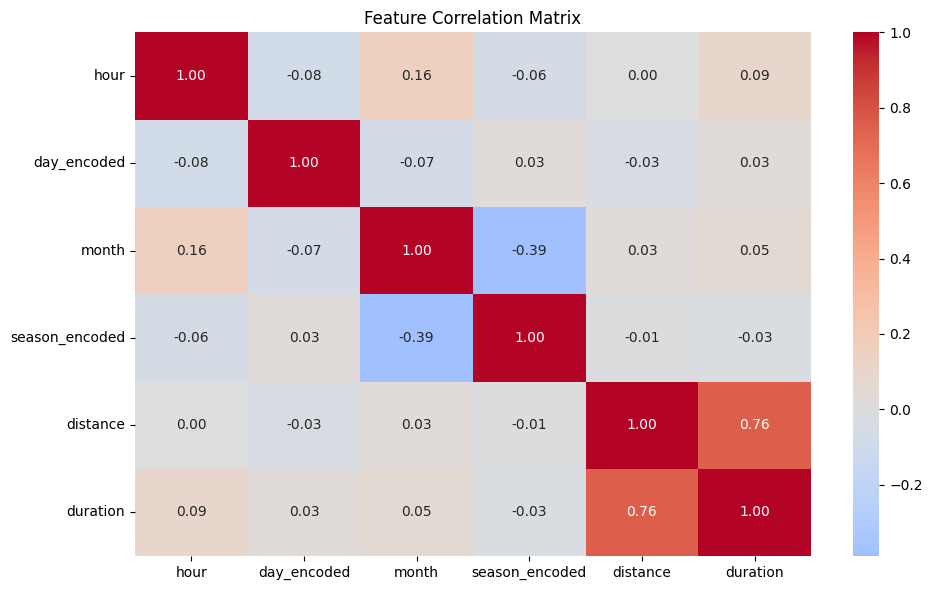

                 hour  day_encoded  month  season_encoded  distance  duration
hour            1.000       -0.077  0.158          -0.062     0.001     0.090
day_encoded    -0.077        1.000 -0.068           0.026    -0.032     0.031
month           0.158       -0.068  1.000          -0.389     0.031     0.052
season_encoded -0.062        0.026 -0.389           1.000    -0.011    -0.030
distance        0.001       -0.032  0.031          -0.011     1.000     0.755
duration        0.090        0.031  0.052          -0.030     0.755     1.000


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df_ml_demand[demand_features].corr()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr.round(3))

In [33]:
#splitting the data into training and testing sets
x_demand_train,x_demand_test,y_demand_train,y_demand_test = train_test_split(x_demand,y_demand,test_size=0.2,random_state=42, stratify=y_demand)

print(f"Training set: {x_demand_train.shape}")
print(f"Test set:     {x_demand_test.shape}")

Training set: (3429, 6)
Test set:     (858, 6)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_demand_train)
x_test_scaled = scaler.transform(x_demand_test)

# Logistic Regression (baseline model)
lr_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 2000,
    random_state = 4
    
)
lr_model.fit(x_train_scaled, y_demand_train)

#Random Forest (primary model)
rf_model = RandomForestClassifier(
    class_weight = 'balanced',
    n_estimators = 100,
    max_depth = 5,
    random_state = 4
)
rf_model.fit(x_demand_train, y_demand_train)

#XGBoost (benchmark model)
xgb_model = XGBClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 4,
    eval_metric = 'mlogloss'
)
xgb_model.fit(x_demand_train, y_demand_train)

models = {
    'Logistic Regression' : (lr_model,x_test_scaled),
    'Random Forest' : (rf_model,x_demand_test),
    'XGBoost' : (xgb_model,x_demand_test)
}

results = []
for name, (model, x_test_data) in models.items():
    y_pred = model.predict(x_test_data)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_demand_test, y_pred),
        'F1-Score': f1_score(y_demand_test, y_pred, average='weighted')
    })
print("\nModel Evaluation Results:")
print(pd.DataFrame(results).set_index('Model').round(4))


Model Evaluation Results:
                     Accuracy  F1-Score
Model                                  
Logistic Regression    0.4429    0.4476
Random Forest          0.7995    0.8003
XGBoost                0.9639    0.9609


CLASSIFICATION REPORT AND CONFUSION MATRIX FOR THE BEST MODEL(XGBOOST)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       246
         Low       1.00      0.68      0.81        96
      Medium       0.94      1.00      0.97       516

    accuracy                           0.96       858
   macro avg       0.98      0.89      0.93       858
weighted avg       0.97      0.96      0.96       858



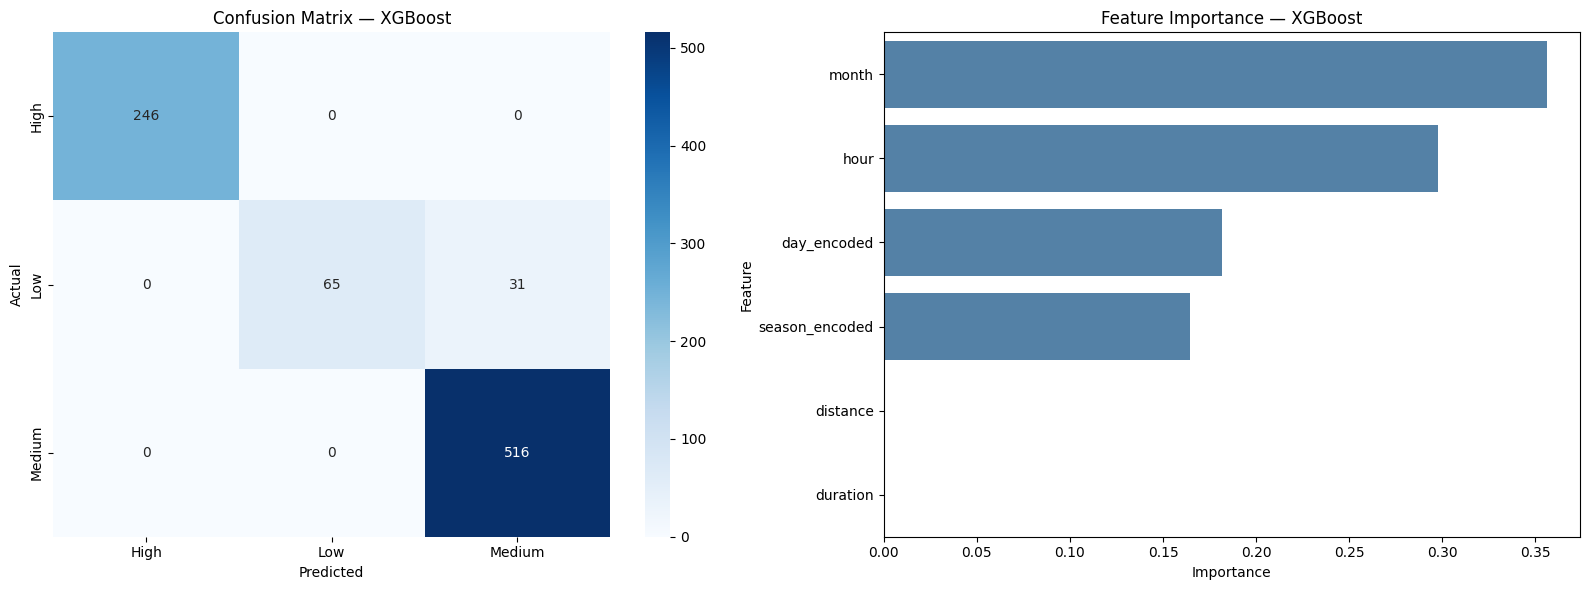

          Feature  Importance
0           month    0.356141
1            hour    0.297687
2     day_encoded    0.181585
3  season_encoded    0.164586
4        distance    0.000000
5        duration    0.000000


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_xgb = xgb_model.predict(x_demand_test)

# Classification report
print(classification_report(
    y_demand_test, y_pred_xgb,
    target_names=target_encoder.classes_
))

# Confusion matrix + Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_demand_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix — XGBoost')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

importance_df = pd.DataFrame({
    'Feature': demand_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance',
            y='Feature', color='steelblue', ax=axes[1])
axes[1].set_title('Feature Importance — XGBoost')

plt.tight_layout()
plt.show()

print(importance_df.reset_index(drop=True).to_string())

In [36]:
# updating the model to use only the most important features based on feature importance
demand_features_final = ['hour', 'day_encoded', 'month', 'season_encoded']

x_demand_final = df_ml_demand[demand_features_final]
x_train_final, x_test_final, y_train, y_test = train_test_split(
    x_demand_final, y_demand, test_size=0.2, random_state=42, stratify=y_demand)

xgb_model.fit(x_train_final, y_train)
y_pred = xgb_model.predict(x_test_final)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

Accuracy: 0.9639
F1: 0.9609


In [45]:
from sklearn.model_selection import cross_val_score

# Cross-validation
cv_scores = cross_val_score(
    xgb_model, x_demand_final, y_demand,
    cv=5, scoring='f1_weighted'
)
print(f"CV F1 Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std:  {cv_scores.std():.4f}")

CV F1 Scores: [0.894  0.9523 0.9277 0.9819 0.9905]
Mean: 0.9493
Std:  0.0355


EARNINGS PREDICTION


In [38]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encoding categorical variables
day_encoder = LabelEncoder()
season_encoder = LabelEncoder()
target_encoder2 = LabelEncoder()

# Transforming categorical variables
df_ml_earnings['day_encoded'] = day_encoder.fit_transform(df_ml_earnings['day_of_week'])
df_ml_earnings['season_encoded'] = season_encoder.fit_transform(df_ml_earnings['season'])
df_ml_earnings['target'] = target_encoder2.fit_transform(df_ml_earnings['earning_category'])

print(f"Target classes: {target_encoder2.classes_}")

# Defining features and target
features_earnings = [
    'hour', 'day_encoded', 'month',
    'season_encoded', 'avg_distance',
    'avg_duration', 'total_trips',
    'demand_score', 'is_event_day'
]

x_earnings = df_ml_earnings[features_earnings]
y_earnings = df_ml_earnings['target']

print(f"X shape: {x_earnings.shape}")
print(f"y shape: {y_earnings.shape}")

Target classes: ['High' 'Low' 'Medium']
X shape: (1561, 9)
y shape: (1561,)


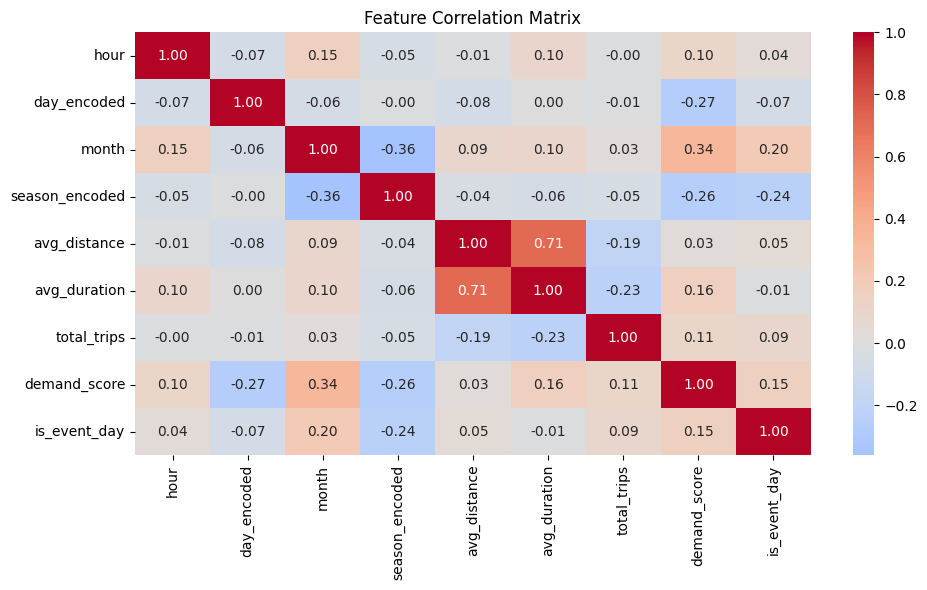

                 hour  day_encoded  month  season_encoded  avg_distance  \
hour            1.000       -0.068  0.151          -0.049        -0.013   
day_encoded    -0.068        1.000 -0.060          -0.004        -0.078   
month           0.151       -0.060  1.000          -0.360         0.089   
season_encoded -0.049       -0.004 -0.360           1.000        -0.037   
avg_distance   -0.013       -0.078  0.089          -0.037         1.000   
avg_duration    0.100        0.005  0.097          -0.058         0.714   
total_trips    -0.004       -0.013  0.029          -0.049        -0.190   
demand_score    0.105       -0.267  0.338          -0.255         0.027   
is_event_day    0.037       -0.073  0.204          -0.240         0.047   

                avg_duration  total_trips  demand_score  is_event_day  
hour                   0.100       -0.004         0.105         0.037  
day_encoded            0.005       -0.013        -0.267        -0.073  
month                  0.097     

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df_ml_earnings[features_earnings].corr()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr.round(3))

In [40]:
# Define features and target for earnings model
features_earnings = [
    'hour', 'day_encoded', 'month',
    'season_encoded', 'avg_distance',
    'avg_duration', 'total_trips',
    'demand_score', 'is_event_day'
]



# Split
x_train_earnings, x_test_earnings, y_train_earnings, y_test_earnings = train_test_split(
    x_earnings, y_earnings, test_size=0.2, random_state=42, stratify=y_earnings)

print(f"Training set: {x_train_earnings.shape}")
print(f"Test set:     {x_test_earnings.shape}")

Training set: (1248, 9)
Test set:     (313, 9)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

scaler = StandardScaler()
x_train_scaled_earnings = scaler.fit_transform(x_train_earnings)
x_test_scaled_earnings = scaler.transform(x_test_earnings)

# Logistic Regression
lr_model_earnings = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
lr_model_earnings.fit(x_train_scaled_earnings, y_train_earnings)

# Random Forest
rf_model_earnings = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model_earnings.fit(x_train_scaled_earnings, y_train_earnings)

# XGBoost
xgb_model_earnings = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model_earnings.fit(x_train_scaled_earnings, y_train_earnings)

models = {
    'Logistic Regression': (lr_model_earnings, x_test_scaled_earnings),
    'Random Forest': (rf_model_earnings, x_test_scaled_earnings),
    'XGBoost': (xgb_model_earnings, x_test_scaled_earnings)
}

results = []
for name, (model, x_test_data) in models.items():
    y_pred = model.predict(x_test_data)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_earnings, y_pred),
        'F1-Score': f1_score(y_test_earnings, y_pred, average='weighted')
    })

print("\nModel Evaluation Results:")
print(pd.DataFrame(results).set_index('Model').round(4))


Model Evaluation Results:
                     Accuracy  F1-Score
Model                                  
Logistic Regression    0.7572    0.7592
Random Forest          0.7668    0.7639
XGBoost                0.7444    0.7422


              precision    recall  f1-score   support

        High       0.85      0.85      0.85       107
         Low       0.76      0.84      0.80       103
      Medium       0.67      0.60      0.64       103

    accuracy                           0.77       313
   macro avg       0.76      0.77      0.76       313
weighted avg       0.76      0.77      0.76       313



C:\Users\olami\AppData\Local\Temp\ipykernel_45464\2291729510.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df2, x='Importance', y='Feature', palette='viridis')


<Axes: xlabel='Importance', ylabel='Feature'>

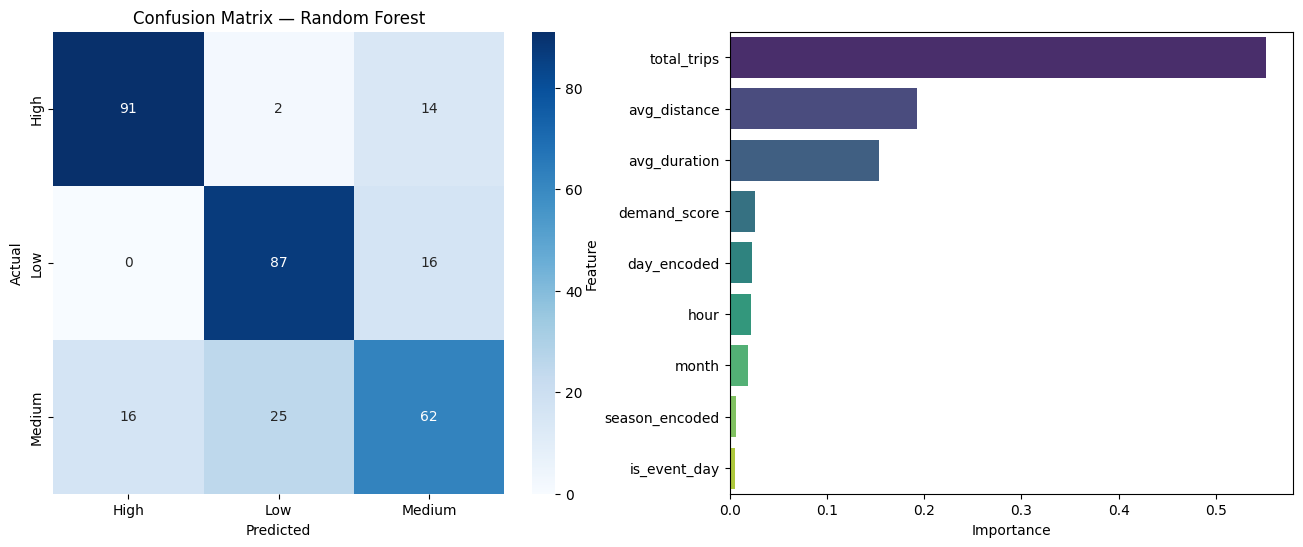

In [42]:
y_pred_best = rf_model_earnings.predict(x_test_scaled_earnings)

print(classification_report(
    y_test_earnings, y_pred_best,
    target_names=target_encoder.classes_
))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test_earnings, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

importance_df2 = pd.DataFrame({
    'Feature': features_earnings,
    'Importance': rf_model_earnings.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df2, x='Importance', y='Feature', palette='viridis')

In [43]:
# Cross-validation
cv_scores = cross_val_score(
    rf_model_earnings, x_train_scaled_earnings, y_train_earnings,
    cv=5, scoring='f1_weighted'
)
print(f"CV F1: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std:  {cv_scores.std():.4f}")

CV F1: [0.8003 0.7729 0.7608 0.7842 0.7712]
Mean: 0.7779
Std:  0.0134
